In [321]:
# !pip install kagglehub

In [322]:
# import kagglehub

# # Download latest version
# path = kagglehub.dataset_download("shivamb/netflix-shows")

# print("Path to dataset files:", path)

In [323]:
# Load csv data info dataframe 
import numpy as np 
import pandas as pd

df = pd.read_csv(r"C:\Users\Rajan Shrestha\.cache\kagglehub\datasets\shivamb\netflix-shows\versions\5\netflix_titles.csv")

In [324]:
df.sample()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
7309,s7310,Movie,Lion's Heart,Karim El Sobky,"Mohamed Ramadan, Hassan Hosny, Horeya Farghaly...",Egypt,"May 9, 2019",2013,TV-14,111 min,"Action & Adventure, International Movies","Kidnapped as a child and raised in the circus,..."


In [326]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   show_id       8807 non-null   str  
 1   type          8807 non-null   str  
 2   title         8807 non-null   str  
 3   director      6173 non-null   str  
 4   cast          7982 non-null   str  
 5   country       7976 non-null   str  
 6   date_added    8797 non-null   str  
 7   release_year  8807 non-null   int64
 8   rating        8803 non-null   str  
 9   duration      8804 non-null   str  
 10  listed_in     8807 non-null   str  
 11  description   8807 non-null   str  
dtypes: int64(1), str(11)
memory usage: 3.9 MB


In [325]:
df.isna().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [327]:
# 1. Clean and convert data types 
df['date_added'] = pd.to_datetime(df['date_added'].str.strip(),format='%B %d, %Y')

# Extract numeric value and unit from duration
df[['duration_value', 'duration_unit']] = df['duration'].str.extract(r'(\d+)\s*(\w+)')
df['duration_unit'] = df['duration_unit'].str.lower()

#Normalize unit names ('season'->'seasons')
df['duration_unit'] = df['duration_unit'].replace({'season':'seasons'})

In [328]:
# 2. Input missing values

## 2.1 Categorical colums: fill with 'Unknown' or Mode
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna(df['country'].mode()[0])
df['rating'] = df['rating'].fillna(df['rating'].mode()[0])

In [329]:
df.isna().sum()

show_id            0
type               0
title              0
director           0
cast               0
country            0
date_added        10
release_year       0
rating             0
duration           3
listed_in          0
description        0
duration_value     3
duration_unit      3
dtype: int64

In [330]:
# Fill missing date_added using release_year (as YYYY-01-01)
df['date_added'] = df['date_added'].fillna(
    pd.to_datetime(df['release_year'].astype(str) + '-01-01')
)

In [331]:
df.isna().sum()

show_id           0
type              0
title             0
director          0
cast              0
country           0
date_added        0
release_year      0
rating            0
duration          3
listed_in         0
description       0
duration_value    3
duration_unit     3
dtype: int64

In [332]:
## 2.2 Impute missing duration using type=based medians
df['duration_value'] = pd.to_numeric(df['duration_value'])
movie_median_dur = df[df['type'] == 'Movie']['duration_value'].median()
tv_median_dur = df[df['type'] == 'TV Show']['duration_value'].median()

In [333]:
df.loc[df['duration_value'].isna() & (df['type'] == 'Movie'), 'duration_value'] = movie_median_dur
df.loc[df['duration_value'].isna() & (df['type'] == 'TV Show'), 'duration_value'] = tv_median_dur
df['duration_unit'] = df['duration_unit'].fillna(df['type'].map({'Movie':'min', 'TV Show':'seasons'}))

In [334]:
# 3. Process comma-separated list features into python list 
df['genres'] = df['listed_in'].str.split(', ')
df['country_list'] = df['country'].str.split(', ')
df['cast_list'] = df['cast'].str.split(', ')

In [335]:
# 4. Feature engineering
df['year_added'] = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month_name()
df['num_cast_members'] = df['cast_list'].apply(lambda x: 0 if x == ['Unknown'] else len(x))

In [336]:
# Drop duplicates based on title and type
df = df.drop_duplicates(subset=['title', 'type']).reset_index(drop=True)

In [337]:
# plot

In [338]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style
sns.set_theme(style="whitegrid")

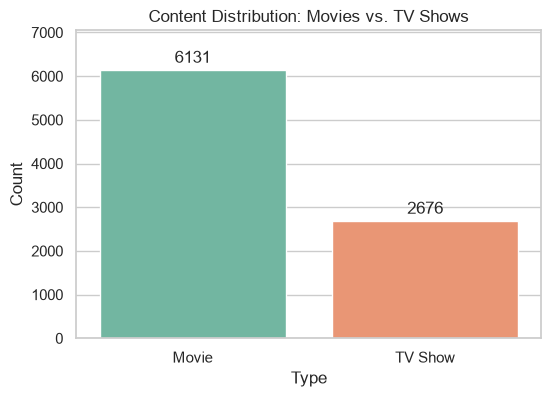

In [339]:
# 1. Distribution of Movies vs. TV Shows

plt.figure(figsize=(6, 4))

ax = sns.countplot(data=df, x='type', hue='type', palette='Set2', legend=False)

# Loop over all containers to annotate every bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Content Distribution: Movies vs. TV Shows')
plt.xlabel('Type')
plt.ylabel('Count')

# Add extra headroom at the top for labels
plt.ylim(0, df['type'].value_counts().max() * 1.15)

plt.show()

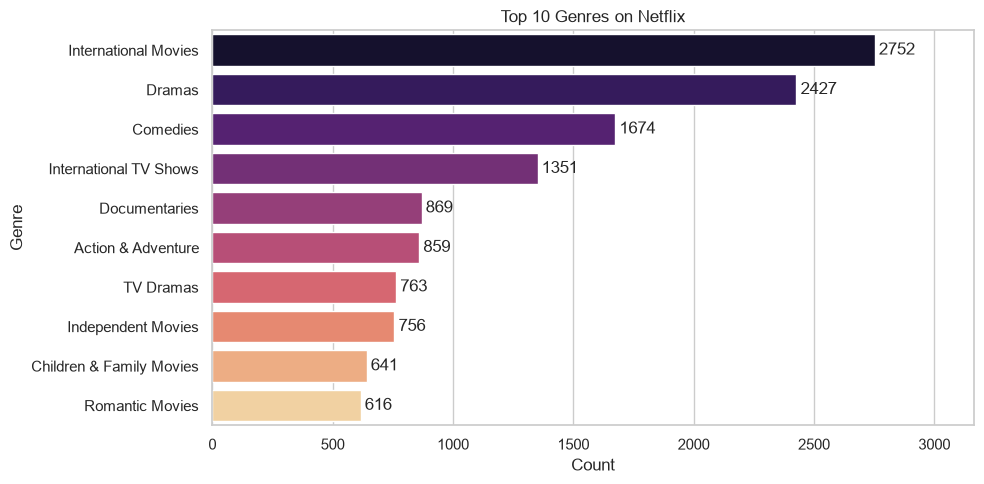

In [340]:
# 2. Top 10 Genres (genres)

# Prepare data
exploded_genres = df.explode('genres').reset_index(drop=True)
top_10 = exploded_genres['genres'].value_counts().head(10).reset_index()
top_10.columns = ['Genre', 'Count']

# Plot without legend
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_10,
    x='Count',
    y='Genre',
    hue='Genre',
    palette='magma',
    legend=False
)

# Add data labels on bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Top 10 Genres on Netflix')
plt.xlabel('Count')
plt.ylabel('Genre')
plt.xlim(0, top_10['Count'].max() * 1.15)
plt.tight_layout()
plt.show()

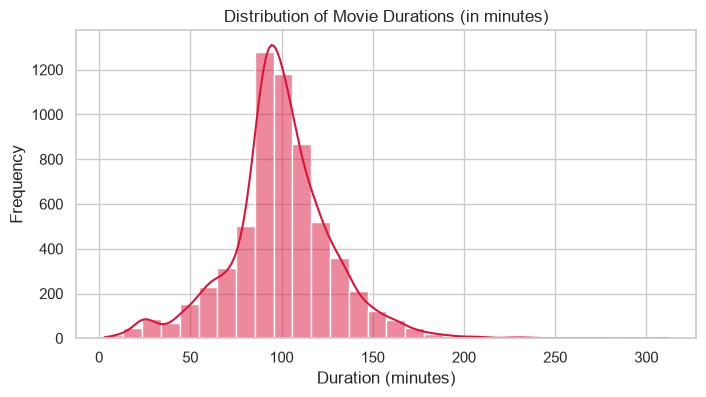

In [341]:
# 3. Movie Duration Distribution (`duration_value`)

movies_df = df[df['type'] == 'Movie']

plt.figure(figsize=(8,4))
sns.histplot(movies_df['duration_value'],kde=True, bins=30,color='crimson')
plt.title('Distribution of Movie Durations (in minutes)')
plt.xlabel('Duration (minutes)')
plt.ylabel('Frequency')
plt.show()

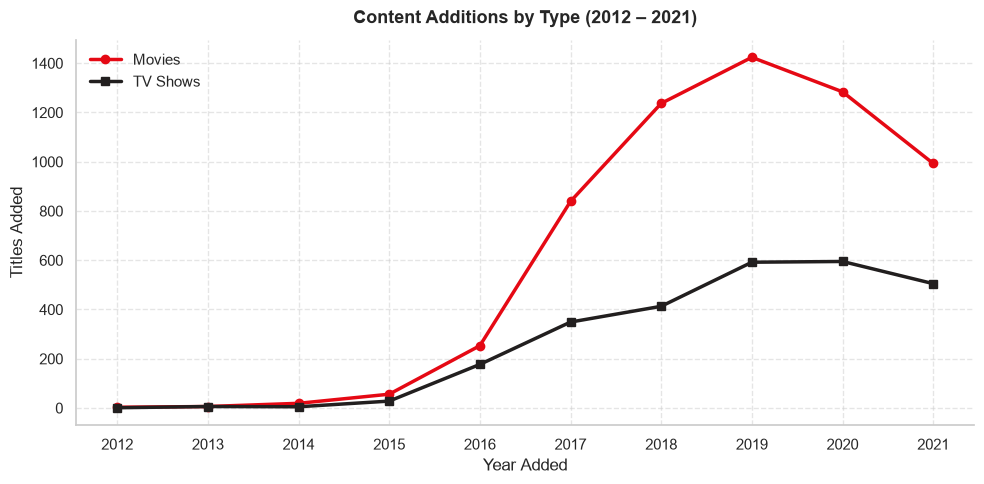

In [357]:
# 4. Content Additions Over Time ('year_added')

### Define color constants
NETFLIX_RED = '#E50914'
DARK_GRAY = '#221F1F'

# Get the latest year dynamically from the dataset
max_year = int(df['year_added'].max())

# Content Additions by Type (2012 – Present / Max Year)
timeline = df[(df['year_added'] >= 2012) & (df['year_added'] <= max_year)].groupby(['year_added', 'type']).size().unstack(fill_value=0)

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(timeline.index, timeline['Movie'], marker='o', linewidth=2.5, color=NETFLIX_RED, label='Movies')
ax.plot(timeline.index, timeline['TV Show'], marker='s', linewidth=2.5, color=DARK_GRAY, label='TV Shows')

ax.set_title(f'Content Additions by Type (2012 – {max_year})', fontsize=13, fontweight='bold', pad=12)
ax.set_xlabel('Year Added')
ax.set_ylabel('Titles Added')
ax.set_xticks(timeline.index)  # Ensures every year is shown on the x-axis
ax.legend(frameon=False)
ax.grid(True, linestyle='--', alpha=0.5)

for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

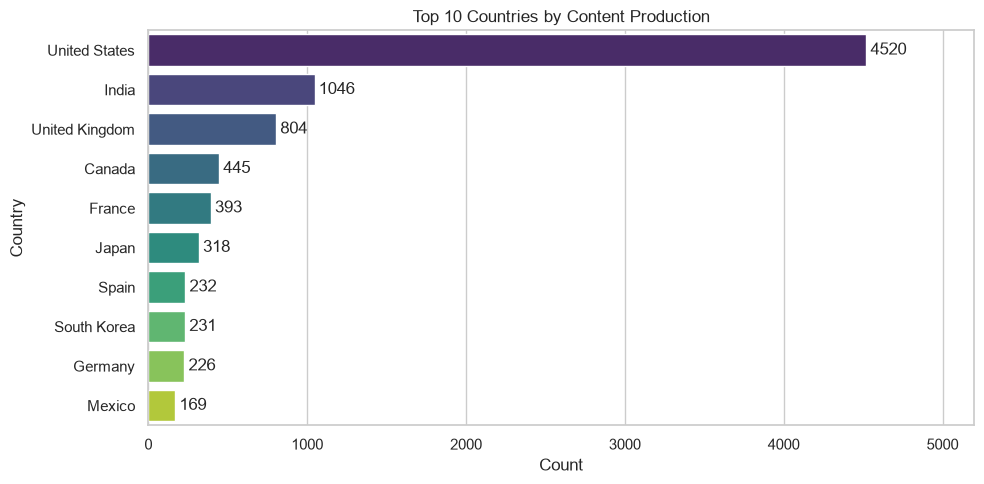

In [363]:
# 5. Top 10 Producing Countries (`country_list`)

## 5.1. Explode country_list and reset index to ensure unique row labels
exploded_countries = df.explode('country_list').reset_index(drop=True)

## 5.2. Get the top 10 countries and counts
top_10_countries = exploded_countries['country_list'].value_counts().head(10).reset_index()
top_10_countries.columns = ['Country', 'Count']

## 5.3. Plot without redundant legend
plt.figure(figsize=(10, 5))
ax = sns.barplot(
    data=top_10_countries,
    x='Count',
    y='Country',
    hue='Country',
    palette='viridis',
    legend=False
)

## 5.4. Add data labels on top/end of each bar
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Top 10 Countries by Content Production')
plt.xlabel('Count')
plt.ylabel('Country')

## Add extra headroom on x-axis for bar labels
plt.xlim(0, top_10_countries['Count'].max() * 1.15)
plt.tight_layout()
plt.show()


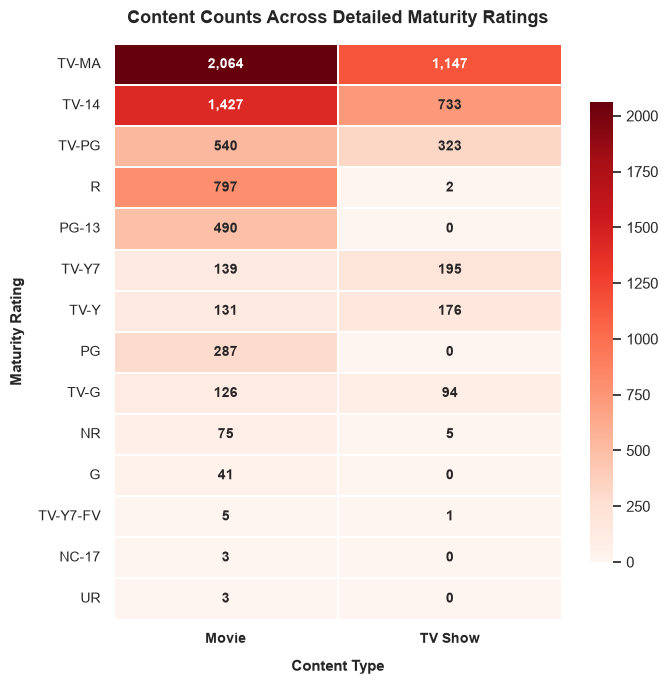

In [364]:
# 6. Content Counts Across Detailed Maturity Ratings

## 6.1. Filter out dirty rating entries (duration values like '66 min', '84 min', '74 min')
valid_ratings = ['TV-MA', 'TV-14', 'TV-PG', 'R', 'PG-13', 'TV-Y7', 'TV-Y', 'PG', 'TV-G', 'NR', 'G', 'TV-Y7-FV', 'NC-17', 'UR']
clean_df = df[df['rating'].isin(valid_ratings)]

## 6.2. Create cross-tabulation and sort by total volume
rating_ct = pd.crosstab(clean_df['rating'], clean_df['type'])
rating_ct = rating_ct.loc[rating_ct.sum(axis=1).sort_values(ascending=False).index]

## 6.3. Plot setup
fig, ax = plt.subplots(figsize=(7, 7))

sns.heatmap(
    rating_ct, 
    annot=True, 
    fmt=',d',                 # Format numbers with commas (e.g., 2,064)
    cmap='Reds',              # Red palette matching Netflix branding
    cbar=True,                # Add colorbar for visual scale
    cbar_kws={'shrink': 0.8},
    linewidths=1.2,           # Cell borders
    linecolor='white',
    annot_kws={'size': 10, 'weight': 'bold'}
)

## 6.4. Custom Styling
ax.set_title('Content Counts Across Detailed Maturity Ratings', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Content Type', fontsize=11, fontweight='semibold', labelpad=10)
ax.set_ylabel('Maturity Rating', fontsize=11, fontweight='semibold', labelpad=10)

# Rotate labels for cleaner layout
plt.xticks(fontsize=10, fontweight='bold')
plt.yticks(rotation=0, fontsize=10)

plt.tight_layout()
plt.show()

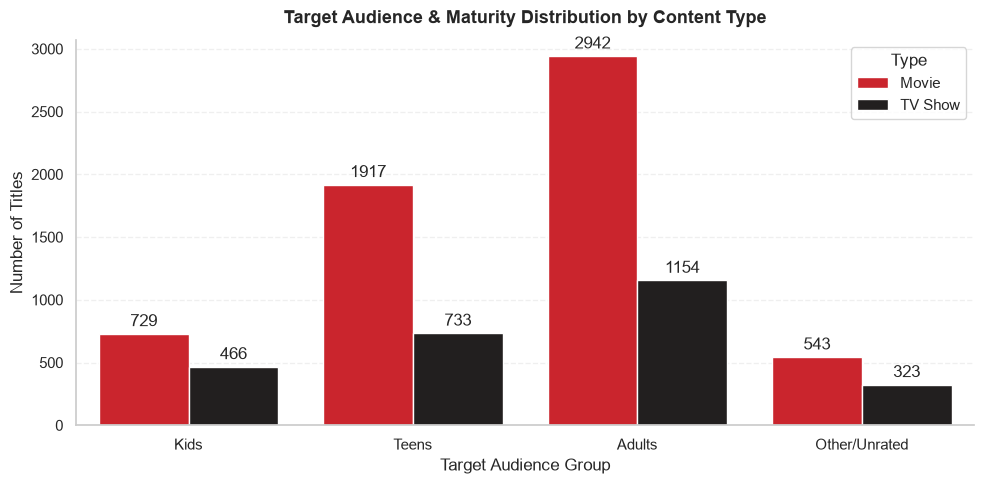

In [360]:
# 7.Target Audience & Maturity Distribution by Content Type

## 7.1. Map ratings to audience categories
rating_map = {
    'TV-Y': 'Kids', 'TV-Y7': 'Kids', 'G': 'Kids', 'TV-G': 'Kids', 'PG': 'Kids', 'TV-Y7-FV': 'Kids',
    'PG-13': 'Teens', 'TV-14': 'Teens',
    'R': 'Adults', 'TV-MA': 'Adults', 'NC-17': 'Adults', 'UR': 'Adults', 'NR': 'Adults'
}

df['target_audience'] = df['rating'].map(rating_map).fillna('Other/Unrated')

### Order for consistent layout
audience_order = ['Kids', 'Teens', 'Adults', 'Other/Unrated']

## 7.2. Create the plot
plt.figure(figsize=(10, 5))

ax = sns.countplot(
    data=df,
    x='target_audience',
    hue='type',
    order=audience_order,
    palette=['#E50914', '#221F1F']
)

# Add data labels on top of bars
for container in ax.containers:
    ax.bar_label(container, padding=3)

plt.title('Target Audience & Maturity Distribution by Content Type', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Target Audience Group')
plt.ylabel('Number of Titles')
plt.legend(title='Type', frameon=True)
plt.grid(True, linestyle='--', alpha=0.3, axis='y')

# Hide top and right borders
for spine in ['top', 'right']:
    ax.spines[spine].set_visible(False)

# Add top padding for numerical labels
plt.ylim(0, df['target_audience'].value_counts().max() * 0.75)

plt.tight_layout()
plt.show()